## Object Oriented Programming

Followed the work of Mr. P Solver's [video](https://www.youtube.com/watch?v=TcaUL1uqG_k&t=1390s) and [repo](https://github.com/lukepolson/youtube_channel/blob/main/Python%20Tutorial%20Series/object_oriented.ipynb).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Starting with `class` in python, it is a cummulation of functions; `def function()` hence it brings this convenience by serving as an orginizer.

Let's define a `class` named Particle; `class Particle():`, Particle here is the object we will be constanly working on.

This class contains several functions: 
* initilization of the particle; `def __init__(self, x, y, z, vx, vy, vz, m)`
* movement of the particle; `def move(self, t)` 
* distance of the particle from its origin; `def get_distance_from_origin(self)`

In [2]:
class Particle():
    def __init__(self, x, y, z, vx, vy, vz, m):
        self.x = x
        self.y = y
        self.z = z
        self.vx = vx
        self.vy = vy
        self.vz = vz
        self.m = m
    def move(self, t):
        # x = v_x * t
        self.x += self.vx * t
        self.y += self.vy * t
        self.z += self.vz * t
    def get_distance_from_origin(self):
        # d = sqrt(x**2 + y**2 + z**2)
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)        

We create an **instance** of the `class` called `Particle`

In [3]:
p1 = Particle(0, 0, 1, 1, 0, 0, 3)      # it should have 7 attributes by its given number of attr. in the class above
p2 = Particle(1, 2, 1, 4, 1, 0, 1)

We can check the attributes of the `Particle`:

In [4]:
print('Attributes of particle 1:')
print(f'x = {p1.x}, y = {p1.y}, z = {p1.z}')
print(f'vx = {p1.vx}, vy = {p1.vy}, vz = {p1.vz}')
print(f'm = {p1.m}')

print('\n')
print('Attributes of particle 2:')
print(f'x = {p2.x}, y = {p2.y}, z = {p2.z}')
print(f'vx = {p2.vx}, vy = {p2.vy}, vz = {p2.vz}')
print(f'm = {p2.m}')

Attributes of particle 1:
x = 0, y = 0, z = 1
vx = 1, vy = 0, vz = 0
m = 3


Attributes of particle 2:
x = 1, y = 2, z = 1
vx = 4, vy = 1, vz = 0
m = 1


By creating a `class` which is structured for an object, we obtain a tool that is repeatedly usable for all the processes that uses that object, here it is `Particle`, i.e. we can define particle 1, 2, ... which are all particles with different attributes (characteristics). Accordingly `p1`, `p2` are called particular instances of the `class` called `Particle`.

As the first part of this `class` we have just given the attributes, now we can also modify them by the given functions; `def move(self, t)` and `def get_distance_from_origin(self)`.

In [5]:
p1.move(2)

Here `def move(2)` function multiplies attributes `vx, vy, vz` with time; `t=2` and add them to attributes `x, y, z`. To see that we can print `x, y, z` attributes again and compare to initial ones. Physically, `move` function takes attribute accounts velocity `vx` multiplies it with time `t` and then adds to the position `x`; $x = v_x \times t$.

In [6]:
print('New location attributes of particle 1:')
print(f'x = {p1.x}, y = {p1.y}, z = {p1.z}')

New location attributes of particle 1:
x = 2, y = 0, z = 1


In [7]:
print('Distance from the origin for particle 1')
print(f'd_1 = {p1.get_distance_from_origin()}')

Distance from the origin for particle 1
d_1 = 2.23606797749979


### Inheritance of Classes

As an example let's consider a physical particle: **proton**,
* It has all the characteristic of a particle
* It has unique traits that are separate from a particle

This is precisely what class inheritance allows us to play with.
* A **child** (proton) class inherits all the traits of its **parent** (particle). Furthermore, the child may have separate traits from its parent.

In [8]:
# class child(parent):
class Proton(Particle):
    def __init__(self, x, y, z, vx, vy, vz):
        # Adding new attribute charge; q
        self.q = 1.6e-19
        # Setting attribute m (particularly for proton)
        self.m = 1.67e-27
        # And then adding it to attributes
        # super calls for the parent class (Particle)
        super(Proton, self).__init__(x, y, z, vx, vy, vz, self.m)
    def move(self, t, Ex, Ey, Ez):
        self.x += self.vx * t + (1/2) * (self.q/self.m) * Ex * t*2
        self.y += self.vy * t + (1/2) * (self.q/self.m) * Ey * t*2
        self.z += self.vz * t + (1/2) * (self.q/self.m) * Ez * t*2
        self.vx += (self.q/self.m) * Ex * t
        self.vy += (self.q/self.m) * Ey * t
        self.vz += (self.q/self.m) * Ez * t
    def get_poisiton(self):
        return np.array([self.x, self.y, self.z])
    def get_velocity(self):
        return np.array([self.vx, self.vy, self.vz])

Define proton class

In [9]:
p = Proton(0,0,1,1,0,0)

It can be seen that, only $6$ attributes are given in the defined class where mass `m` is redefined in the function by `self.m` together with the new additional attribute `q` with `self.q`.

In [10]:
print('Attributes of Proton')
print(f'p_x = {p.x}, p_x = {p.y}, p_x = {p.z}')
print(f'p_vx = {p.vy}, p_vx ={p.vy}, p_vz ={p.vz}')
print(f'm = {p.m}, q = {p.q}')

Attributes of Proton
p_x = 0, p_x = 0, p_x = 1
p_vx = 0, p_vx =0, p_vz =0
m = 1.67e-27, q = 1.6e-19


In [11]:
p.move(0.005, 5.10e-10, 6.10e-10, 7.10e-10 )
print('New position attributes of proton:')
print(f'x = {p.x}, y = {p.y}, z = {p.z}')

print('\n')
print('New velocity attributes of proton:')
print(f'vx = {p.vx}, vy = {p.vy}, z = {p.vz}')

New position attributes of proton:
x = 0.005244311377245509, y = 0.0002922155688622754, z = 1.000340119760479


New velocity attributes of proton:
vx = 1.0002443113772455, vy = 0.0002922155688622754, z = 0.0003401197604790419


In [12]:
p.get_poisiton()
print('New position attributes of proton:')
print(f'{p.get_poisiton()}')

New position attributes of proton:
[5.24431138e-03 2.92215569e-04 1.00034012e+00]


In [13]:
p.get_velocity()
print('New velocity attributes of proton:')
print(f'{p.get_velocity()}')

New velocity attributes of proton:
[1.00024431e+00 2.92215569e-04 3.40119760e-04]


### Intermediate
A class that contains all the information about a given projectile motion problem
* `r0`: initiall $(x,y)$ position of the particle
* `v0`: initiall $(v_x,v_y)$ velocity of the particle
* `t_span`: time span over which we consider the motion of particle

Then we define additional properties (functions) of the motion
* `get_peak_y` returns the maximum height obtained from the particle
* `get_peak_x` returns the horizontal distance corresponding to the peak $y$ value
* `get_peak_t` returns the time when maxium height is reached
* `get_x_landing`return the horizontal distance travelled by the projectile (before it hits the ground)

In [14]:
class Projectile():
    def __init__(self, r0, v0, g, t_span):
        self.t = t_span
        x0, y0 = r0
        vx0, vy0 = v0
        # positions
        self.x = x0 + vx0*self.t
        # position y also contains gravitational effect
        # y0; initial position y
        # vy0; initial velocity y
        # g; gravitational acceleration
        # y = y0 + vy0*t + (-1/2)*g*t^2
        self.y = y0 + vy0*self.t + -(1/2)*g*self.t**2
    def get_peak_y(self):
        # return max height on y axis
        return max(self.y)
    def get_peak_x(self):
        # return max distance on x axis by max y
        return self.x[np.argmax(self.y)]
    def get_peak_t(self):
        # return peak time by max y
        return self.t[np.argmax(self.y)]
    def get_x_landing(self):
        # turning points
        x_after_peak = self.x[self.t>self.get_peak_t()]
        y_after_peak = self.y[self.t>self.get_peak_t()]
        return x_after_peak[np.argmin(np.abs(y_after_peak))]

Create a projectile and plot

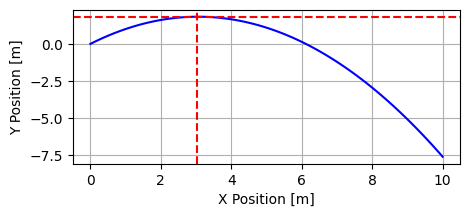

In [15]:
# Defining attributes for the projectile
p = Projectile(r0=[0,0],
               v0=[5,6],
               g=9.81,
               t_span = np.linspace(0,2,100))

plt.figure(figsize=(5,2))
plt.plot(p.x, p.y,'blue')
plt.axhline(p.get_peak_y(), color='r', ls='--')
plt.axvline(p.get_peak_x(), color='r', ls='--')
plt.xlabel('X Position [m]')
plt.ylabel('Y Position [m]')
plt.grid()
plt.show()

In [16]:
p.get_peak_t()

0.6060606060606061

In [17]:
# Consider array of angles
# with equal spacing of 100 steps between 0-pi/2
thetas = np.linspace(0,np.pi/2,100)
v0 = 5
vys = v0*np.sin(thetas)
vxs = v0*np.cos(thetas)

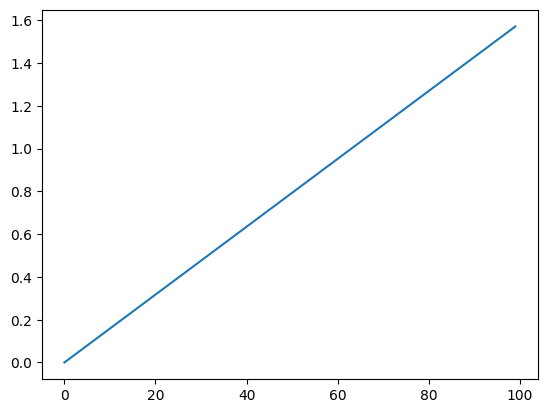

In [18]:
plt.plot(thetas)

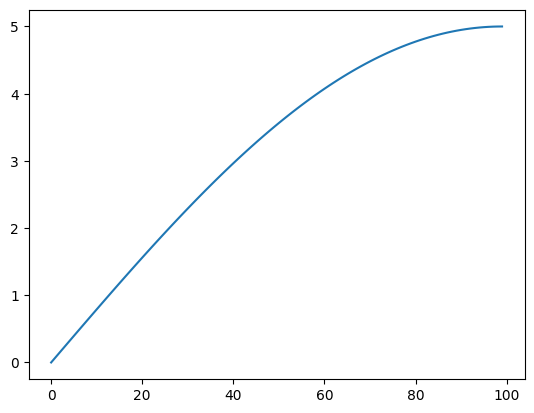

In [19]:
plt.plot(vys)

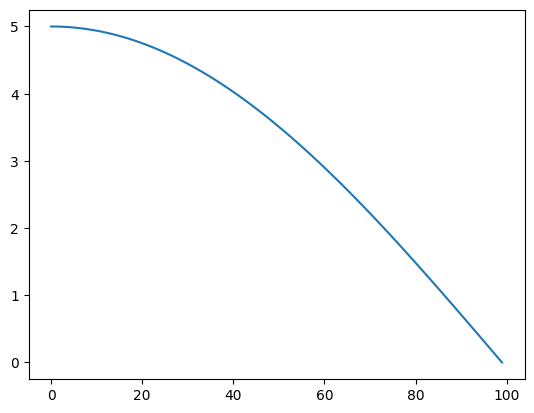

In [20]:
plt.plot(vxs)

Here we can use list comprehension which offers a shorter syntax when you want to create a new list based on the values of an existing list.

---
**Example**:

Based on a list of fruits, you want a new list, containing only the fruits with the letter "a" in the name.

Without list comprehension you will have to write a `for` statement with a conditional test inside:

In [21]:
fruits = ["apple", "banana", "cherry", "kiwi", "mango"]
newlist = []

for x in fruits:
  if "a" in x:
    newlist.append(x)

print(newlist)

['apple', 'banana', 'mango']


With list comprehension:

In [22]:
fruits = ["apple", "banana", "cherry", "kiwi", "mango"]

newlist = [x for x in fruits if "a" in x]

print(newlist)

['apple', 'banana', 'mango']


---

List comprehension: `[ ]` presents a cleaner way of writing the code.

In [23]:
[i**2 for i in range(5)]

[0, 1, 4, 9, 16]

In [24]:
thetas = np.linspace(0,np.pi/2,100)
v0 = 5
vys = v0*np.sin(thetas)
vxs = v0*np.cos(thetas)

# Using list comprehension in the class
ps = [Projectile(r0=[0,0],
                v0=[vx,vy],
                g=9.81,
                t_span = np.linspace(0,3,300)) for vx,vy in zip(vxs,vys)]

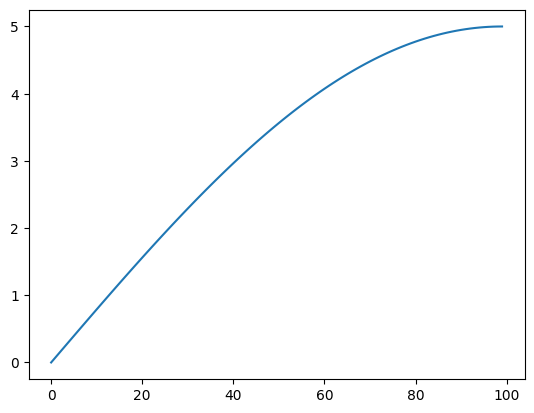

In [25]:
plt.plot(vys)

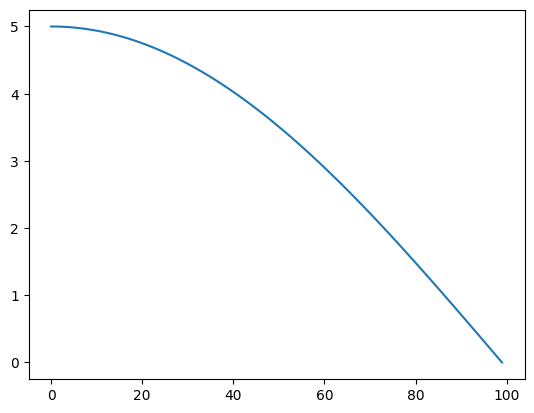

In [26]:
plt.plot(vxs)

There is no difference by the result, but presenting cleaner and easy to use code structure.

Compute maximum heights and maximum distances travelled

In [27]:
# Again using list comprehension
max_heights = [p.get_peak_y() for p in ps]
x_landings = [p.get_x_landing() for p in ps]

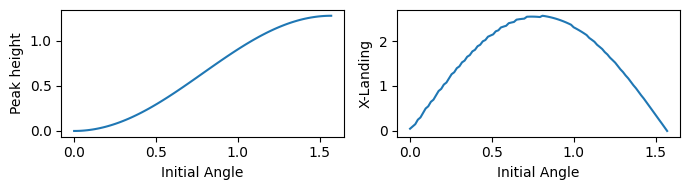

In [30]:
fig = plt.figure(figsize=(7,2))
plt.subplot(121)
plt.plot(thetas, max_heights)
plt.xlabel('Initial Angle')
plt.ylabel('Peak height')
plt.subplot(122)
plt.plot(thetas, x_landings)
plt.xlabel('Initial Angle')
plt.ylabel('X-Landing')
fig.tight_layout()
plt.show()

To make it even simpler:
* `Projectiles` is a class, as its attributes, contains many instances of the `Projectile` class

In [31]:
class Projectiles():
    def __init__(self, r0, v0s, g, t_span):
        self.ps = [Projectile(r0=r0, 
                              v0=v0,
                              g=g,
                              t_span=t_span) for v0 in v0s]
    def get_max_heights(self):
        return [p.get_peak_y() for p in self.ps]
    def get_x_landings(self):
        return [p.get_x_landing() for p in self.ps]
    def get_projectiles(self):
        return self.ps

Create many projectiles

In [32]:
thetas = np.linspace(0,np.pi/2,100)
v0 = 5
vys = v0*np.sin(thetas)
vxs = v0*np.cos(thetas)

ps = Projectiles(r0=[0,0],
                v0s=np.array([vxs, vys]).T,
                g = 9.81,
                t_span= np.linspace(0,3,300))

Get the horizontal landing positions of all the particles

In [33]:
x_landings = ps.get_x_landings()

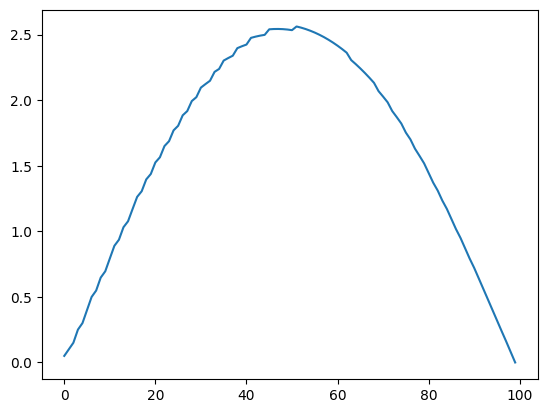

In [35]:
plt.plot(x_landings)

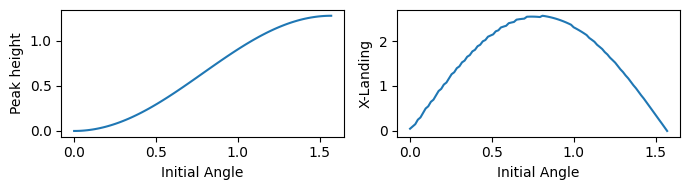

In [36]:
fig = plt.figure(figsize=(7,2))
plt.subplot(121)
plt.plot(thetas, max_heights)
plt.xlabel('Initial Angle')
plt.ylabel('Peak height')
plt.subplot(122)
plt.plot(thetas, x_landings)
plt.xlabel('Initial Angle')
plt.ylabel('X-Landing')
fig.tight_layout()
plt.show()

### Advanced

In practice, a real projectile may experience arbitrary forces acting on it (gravity, air friction, electric/magnetic field, etc). By deifning a more advanced class, we can take into account all these possibilities:

* Now we'll include a function F(t,x,y,vx,vy,m) which is a general force function acting on the particle. This can encompass all sorts of conditions

In [37]:
class Projectile():
    def __init__(self,r0,v0,t,F,m,*args):
        self.t = t
        self.x0, self.y0 = r0
        self.vx0, self.vy0 = v0
        self.F = F
        self.m = m
        self.args = args
    def solve_motion(self):
        def dSdt(t, S, *args):
            x, vx, y, vy = S
            return [vx, self.F(t,x,y,vx,vy,m,*args)[0]/self.m,
                    vy, self.F(t,x,y,vx,vy,m,*args)[1]/self.m]
        self.solution = solve_ivp(dSdt, [min(self.t), max(self.t)],
                                  [self.x0,self.vx0,self.y0,self.vy0],
                                  t_eval=self.t, args=self.args)
        self.x, self.vx, self.y, self.vy = self.solution.y
    def get_peak_y(self):
        return max(self.y)
    def get_peak_x(self):
        return self.x[np.argmax(self.y)]
    def get_peak_t(self):
        return self.t[np.argmax(self.y)]
    def get_x_landing(self):
        x_after_peak = self.x[self.t>self.get_peak_t()]
        y_after_peak = self.y[self.t>self.get_peak_t()]
        return x_after_peak[np.argmin(np.abs(y_after_peak))]

Define a couple force functions

* force_1 for quadratic air friction
* force_2 for linear air friction

In [38]:
def force_1(t,x,vx,y,vy,m,g,b):
    return [-b*np.sqrt(vx**2+vy**2)*vx, -b*np.sqrt(vx**2+vy**2)*vy - m*g]
def force_2(t,x,vx,y,vy,m,g,b):
    return [-b*vx, -b*vy - m*g]

Set up particles

* p1 experiences gravity and quadratic air friction
* p2 experiences gravity and linear air friction

In [39]:
# Conditions
r0=[0,0]
v0=[10*np.cos(np.pi/4),10*np.sin(np.pi/4)]
t = np.linspace(0,1,1000)
m=1
g = 9.8
b1 = 1
b2 = 5

# Paricle Motion
p1 = Projectile(r0, v0, t, force_1, m, g, b1)  
p2 = Projectile(r0, v0, t, force_2, m, g, b2)  
p1.solve_motion()
p2.solve_motion()

And Plot

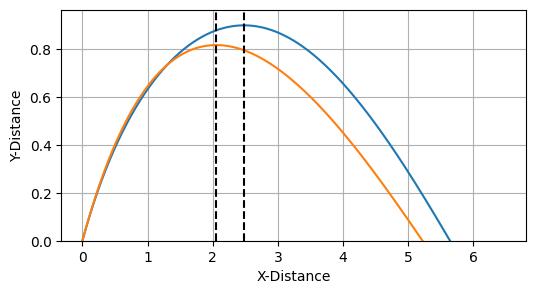

In [40]:
plt.figure(figsize=(6,3))
plt.plot(p1.x,p1.y)
plt.plot(p2.x,p2.y)
plt.axvline(p1.get_peak_x(), color='k', ls='--', label='Quadratic Friction')
plt.axvline(p2.get_peak_x(), color='k', ls='--', label='Linear Friction')
plt.ylim(bottom=0)
plt.grid()
plt.xlabel('X-Distance')
plt.ylabel('Y-Distance')
plt.show()

### Exercise:

For the case of air friction;

1. Modify the Projectiles class (from intermediate portion of this video) to take in a bunch of Projectile classes (from the advanced portion of the video), and solve for the motion of all the projectiles.

In [41]:
# Projectiles class for the air friction case:
# *args collects multiple positional arguments into a tuple

# Projectile (with air drag)
class Projectile:
    def __init__(self, r0, v0, t, F, m, *args):
        self.x0, self.y0 = r0
        self.vx0, self.vy0 = v0

        self.t = t
        self.F = F
        self.m = m
        self.args = args

        self.solution = None

    def solve_motion(self):
        def dSdt(t, S):
            x, vx, y, vy = S
            Fx, Fy = self.F(t, x, y, vx, vy, self.m, *self.args)
            return [vx, Fx / self.m, vy, Fy / self.m]

        self.solution = solve_ivp(
            dSdt,
            [self.t[0], self.t[-1]],
            [self.x0, self.vx0, self.y0, self.vy0],
            t_eval=self.t
        )

In [42]:
# Multiple Projectiles
class Projectiles:
    def __init__(self, r0, v0s, t, F, m, *args):
        self.ps = []

        for v0 in v0s:
            p = Projectile(r0, v0, t, F, m, *args)
            p.solve_motion()
            self.ps.append(p)

    def get_projectiles(self):
        return self.ps

    def get_max_heights(self):
        return [max(p.solution.y[2]) for p in self.ps]

    def get_xlandings(self):
        landings = []

        for p in self.ps:
            y = p.solution.y[2]
            x = p.solution.y[0]

            idx = np.where(y <= 0)[0]
            if len(idx) > 0:
                landings.append(x[idx[0]])
            else:
                landings.append(None)

        return landings

    def plot(self):
        plt.figure()

        for p in self.ps:
            x = p.solution.y[0]
            y = p.solution.y[2]
            plt.plot(x, y)

        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Projectile motion with air resistance")
        plt.grid()
        plt.show()

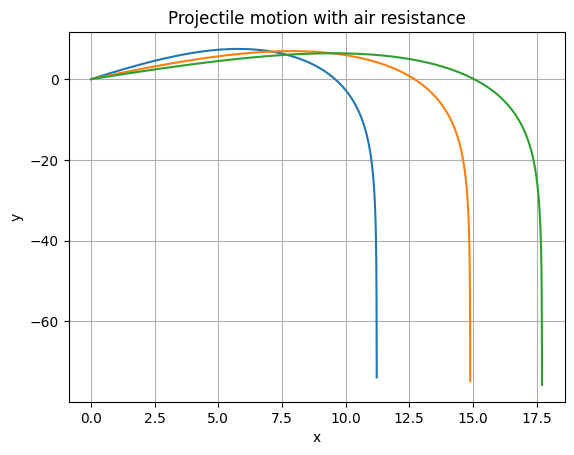

Max heights: [7.4869658941191926, 6.945125743486591, 6.413107433316278]
Landing x positions: [0.0, 0.0, 0.0]


In [43]:
# Force with air drag
def drag_force(t, x, y, vx, vy, m, k, g):
    v = np.sqrt(vx**2 + vy**2)

    Fx = -k * v * vx
    Fy = -m * g - k * v * vy

    return Fx, Fy


# Run simulation
t = np.linspace(0, 10, 500)

r0 = (0, 0)
v0s = [(10, 20), (15, 20), (20, 20)]

ps = Projectiles(r0, v0s, t, drag_force, 1.0, 0.1, 9.81)

# Plot trajectories
ps.plot()

# Extra results
print("Max heights:", ps.get_max_heights())
print("Landing x positions:", ps.get_xlandings())

---

2. Create an instance of the `Projectiles` class that contains a bunch of particles with the same initial position, launch speed, quadratic air friction, and gravity as above, but modify the angles such that there is 100 launch angles between $\theta = 0.01$ and $\theta = \pi/2 - 0.01$.

In [44]:
# Generate angles
# theta_first = 0.01 and theta_last = pi/2 - 0.01
theta_vals = np.linspace(0.01, np.pi/2 - 0.01, 100)

In [45]:
# Convert velocity vectors
v0_mag = 20  # choose your launch speed

v0s = [(v0_mag * np.cos(theta), v0_mag * np.sin(theta)) 
       for theta in theta_vals]

In [46]:
# Create Projectiles object
t = np.linspace(0, 10, 500)
r0 = (0, 0)

ps = Projectiles(r0, v0s, t, drag_force, 1.0, 0.1, 9.81)

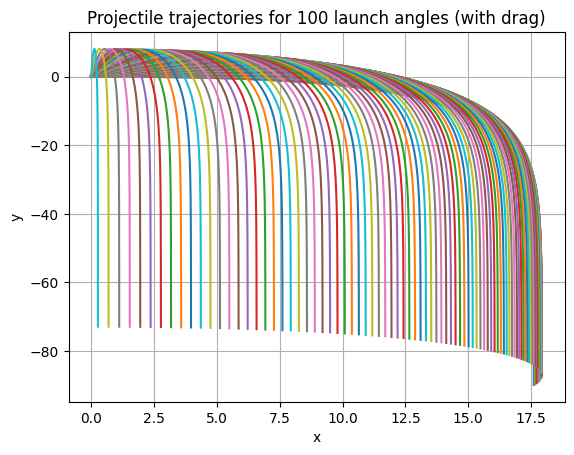

In [47]:
# Plot
plt.figure()

for p in ps.get_projectiles():
    x = p.solution.y[0]
    y = p.solution.y[2]
    plt.plot(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Projectile trajectories for 100 launch angles (with drag)")
plt.grid()
plt.show()

---

3. Use the `get_max_heights` and `get_xlandings` to plot the maximum height and maximum horizontal distance as a function of initial launch angle $\theta$.

In [48]:
# Reuse setup from exercise 2
theta_vals = np.linspace(0.01, np.pi/2 - 0.01, 100)

v0_mag = 20
v0s = [(v0_mag * np.cos(theta), v0_mag * np.sin(theta)) 
       for theta in theta_vals]

t = np.linspace(0, 10, 500)
r0 = (0, 0)

ps = Projectiles(r0, v0s, t, drag_force, 1.0, 0.1, 9.81)

In [49]:
# Generate results in your class
max_heights = ps.get_max_heights()
ranges = ps.get_xlandings()

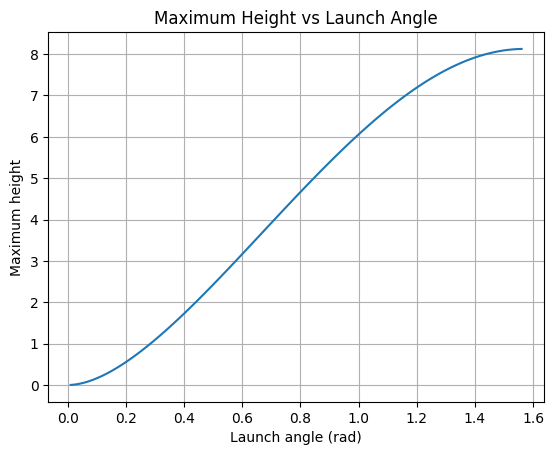

In [50]:
# Plot max height vs angle
plt.figure()

plt.plot(theta_vals, max_heights)
plt.xlabel("Launch angle (rad)")
plt.ylabel("Maximum height")
plt.title("Maximum Height vs Launch Angle")
plt.grid()

plt.show()